<a href="https://colab.research.google.com/github/shaikhMirtizaFES/Introduction-to-AI-Assignment-2/blob/main/Hotdog_Classifier_Irtiza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random

print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [11]:
# Unzip the data
!unzip -q hot-dog-not-hot-dog.zip

# Define paths
train_path = "/content/train"
test_path = "/content/test"

# Count images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))
test_count = len(os.listdir(os.path.join(test_path, "hot_dog"))) + len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Hot dog training images: {hot_dog_count}")
print(f"Not hot dog training images: {not_hot_dog_count}")
print(f"Total test images: {test_count}")

replace seefood/test/hot_dog/133012.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Hot dog training images: 249
Not hot dog training images: 249
Total test images: 500


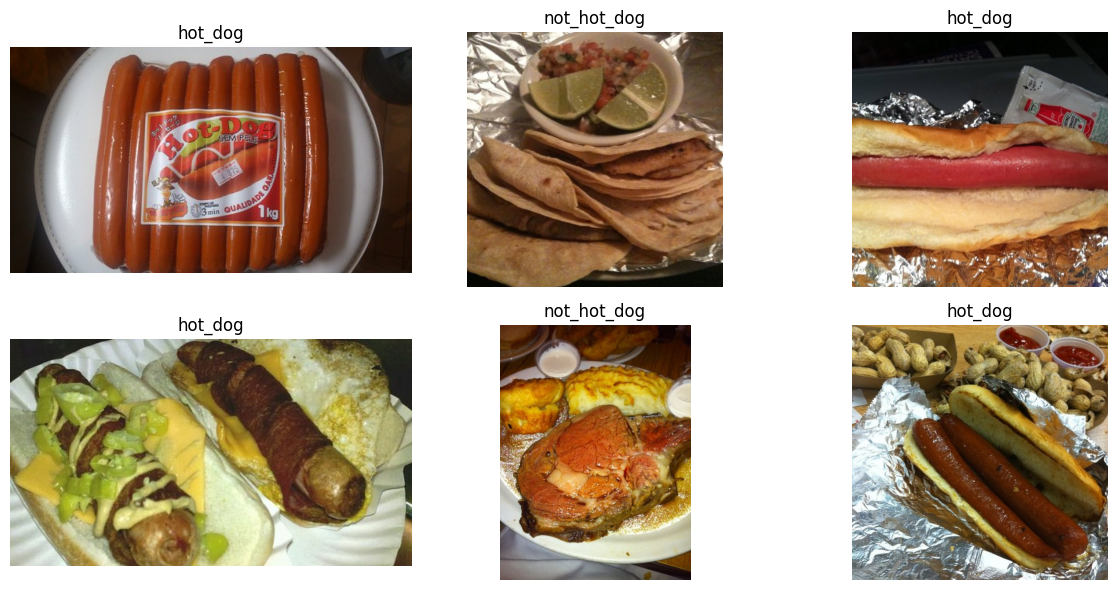

Image shape (Height, Width, Channels): (512, 512, 3)


In [12]:
plt.figure(figsize=(12,6))
for i in range(6):
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    img = plt.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Print shape of the last loaded image
print(f"Image shape (Height, Width, Channels): {img.shape}")

In [13]:
IMG_HEIGHT, IMG_WIDTH = 64, 64
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='binary', subset='training')

validation_generator = train_datagen.flow_from_directory(
    train_path, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='binary', subset='validation')

# Build ANN
ann_model = keras.Sequential([
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_ann = ann_model.fit(train_generator, validation_data=validation_generator, epochs=10)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4825 - loss: 1.4814 - val_accuracy: 0.5000 - val_loss: 1.7312
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5400 - loss: 0.9796 - val_accuracy: 0.5000 - val_loss: 0.8732
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5800 - loss: 0.6932 - val_accuracy: 0.5204 - val_loss: 0.7146
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6750 - loss: 0.6102 - val_accuracy: 0.5306 - val_loss: 0.7173
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7350 - loss: 0.5596 - val_accuracy: 0.5714 - val_loss: 0.7108
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7450 - loss: 0.5425 - val_accuracy: 0.5714 - val_loss: 0.7213
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7575 - loss: 0.5187 - val_accuracy: 0.5714 - val_loss: 0.7345
Epoch 8/10
13/13 ━━━━━━━━━━━━━

In [14]:
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'), # The "Your Turn" layer
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_cnn = cnn_model.fit(train_generator, validation_data=validation_generator, epochs=15)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.5050 - loss: 0.7001 - val_accuracy: 0.5000 - val_loss: 0.7015
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.5300 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6905
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.5800 - loss: 0.6735 - val_accuracy: 0.6020 - val_loss: 0.6728
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.5900 - loss: 0.6710 - val_accuracy: 0.6020 - val_loss: 0.6601
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.5825 - loss: 0.6646 - val_accuracy: 0.5612 - val_loss: 0.6890
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.6625 - loss: 0.6388 - val_accuracy: 0.6020 - val_loss: 0.6765
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.7100 - loss: 0.5778 - val_accuracy: 0.6224 - val_loss: 0.6766
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.7475 - loss: 0.5189 - val_accuracy: 0.

In [15]:
# Data Augmentation
augmented_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)

train_augmented = augmented_datagen.flow_from_directory(
    train_path, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='binary', subset='training')

# Build Final Model with Dropout
final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_final = final_model.fit(train_augmented, validation_data=validation_generator, epochs=15)

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.4800 - loss: 0.7312 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step - accuracy: 0.4900 - loss: 0.6938 - val_accuracy: 0.4898 - val_loss: 0.6931
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.4725 - loss: 0.6953 - val_accuracy: 0.4694 - val_loss: 0.6928
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.5150 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.5200 - loss: 0.6924 - val_accuracy: 0.5102 - val_loss: 0.6924
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.5325 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.5500 - loss: 0.6894 - val_accuracy: 0.4796 - val_loss: 0.6915
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


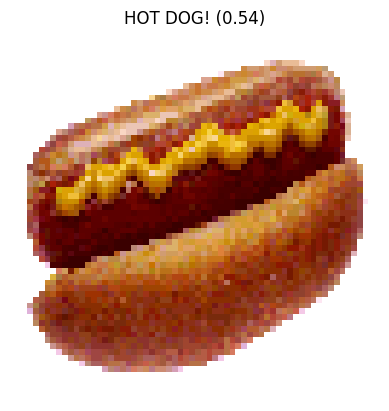

In [18]:
import requests
from io import BytesIO
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image(img_url):
    # Add User-Agent header to mimic a browser, which can sometimes resolve issues with servers blocking requests
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    response = requests.get(img_url, headers=headers)

    # Check if the request was successful
    if response.status_code != 200:
        print(f"Error: Could not retrieve image from {img_url}. Status code: {response.status_code}")
        return

    # Check content type to ensure it's an image
    content_type = response.headers.get('Content-Type', '')
    if 'image' not in content_type:
        print(f"Error: Content type is not an image. Content-Type: {content_type}")
        print("Response content start (first 100 bytes):", response.content[:100]) # Print first 100 bytes for debugging
        return

    try:
        img = image.load_img(BytesIO(response.content), target_size=(IMG_HEIGHT, IMG_WIDTH))
    except Exception as e:
        print(f"Error loading image: {e}")
        print("It's possible the URL does not point to a valid image file, or the file is corrupted.")
        print(f"Content-Type: {content_type}")
        print("Response content start (first 100 bytes):", response.content[:100])
        return

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = final_model.predict(img_array)[0][0]
    result = "HOT DOG!" if prediction > 0.5 else "NOT A HOT DOG!"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    plt.imshow(img)
    plt.title(f"{result} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

# TEST IT HERE
predict_image("https://upload.wikimedia.org/wikipedia/commons/b/b1/Hot_dog_with_mustard.png")